In [3]:
# Import necessary libraries for environment setup
import os
import sys
import warnings
warnings.filterwarnings("ignore")

# Set the working directory to the project root (for Jupyter, use current directory)
project_root = os.getcwd()
os.chdir(project_root)
# Add the project root to the system path for module imports
sys.path.append(project_root)


# Import libraries for data handling and visualization
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
# Set up logging to capture important information during execution
logging.info("Environment setup complete. Libraries imported successfully.")

# Import general use libraries for ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore

# Import libraries for image processing
from PIL import Image
from PIL import ImageFilter
from PIL import ImageEnhance

# Import loading bars
import tqdm
from tqdm import tqdm



2025-11-25 00:05:59,924 - INFO - Environment setup complete. Libraries imported successfully.


Converted data loaded successfully.
Index: 2763
Label: tf.Tensor([0. 0. 1. 0. 0. 0. 0. 0. 0. 0.], shape=(10,), dtype=float32)


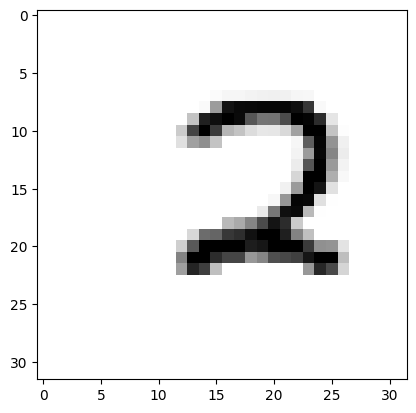

In [ ]:
# Load converted_data from the file (Original images with white background, black digits)
import pickle
import random
converted_data_path = os.path.join(project_root,'converted_data.pkl')
with open(converted_data_path, 'rb') as f:
    converted_data = pickle.load(f)
    print("Converted data loaded successfully.")
    # Check if the data is loaded correctly
    index = random.randint(0, len(converted_data)-1)
    random_element = converted_data[index]
    plt.imshow(random_element[0], cmap='gray')
    print("Index:", index)
    print("Label:",random_element[1])

In [7]:
# Shuffle dataset with random library and split into train and test sets via sklearn

import random
from sklearn.model_selection import train_test_split

# Assuming 'converted_data' is your list of (image_tensor, label) tuples
# Shuffle the dataset using random.shuffle
random.shuffle(converted_data)

# Separate the data into features (X) and labels (y)
X = [item[0] for item in converted_data]
y = [item[1] for item in converted_data]

# Split the data into training and testing sets using sklearn's train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # Adjust test_size as needed

# Reshape X
X_train = np.array(X_train).reshape(-1, 32, 32, 1) # Convert X_train and X_test to NumPy arrays before reshaping
X_test = np.array(X_test).reshape(-1, 32, 32, 1)

# Convert y_train and y_test from list of tensors to numpy arrays
y_train = np.stack([y.numpy() for y in y_train])
y_test = np.stack([y.numpy() for y in y_test])

# Print out shapes
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(105188, 32, 32, 1)
(26297, 32, 32, 1)
(105188, 10)
(26297, 10)


In [8]:
# Define the CNN model
model = keras.Sequential([
    # First convolutional layer with 32 filters, kernel size 3x3, ReLU activation, and input shape (32,32,1)
    layers.Conv2D(30, (3,3), activation='relu', input_shape=(32,32,1)),
    
    # MaxPooling layer to reduce spatial dimensions by 2x2
    layers.MaxPooling2D((2,2)),

    # Second convolutional layer with 64 filters
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten layer to convert 2D feature maps to 1D feature vector
    layers.Flatten(),

    # Fully connected layer with 64 neurons
    layers.Dense(64, activation='relu'),

    # Output layer with 10 neurons for classification (softmax for multi-class classification)
    layers.Dense(10, activation='softmax')
])

# Define Adam optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

# Compile the model with categorical crossentropy loss, Adam optimizer, and accuracy metric
model.compile(optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print the model summary to see its structure
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 30)     │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        17,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,814 (647.71 KB)

 Trainable params: 165,814 (647.71 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Add data augmentation to your training process
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define the data augmentation generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=0.1
)

# Fit the generator to your training data (optional for grayscale images)
datagen.fit(X_train)

# Use the generator in model training
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=15,  # Adjust epochs as needed
    validation_data=(X_test, y_test)
)

# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test accuracy:', test_acc)

Epoch 1/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - accuracy: 0.9034 - loss: 0.3108 - val_accuracy: 0.9807 - val_loss: 0.0640
Epoch 2/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9722 - loss: 0.0936 - val_accuracy: 0.9884 - val_loss: 0.0394
Epoch 3/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9794 - loss: 0.0687 - val_accuracy: 0.9895 - val_loss: 0.0351
Epoch 4/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9827 - loss: 0.0573 - val_accuracy: 0.9914 - val_loss: 0.0288
Epoch 5/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.9856 - loss: 0.0488 - val_accuracy: 0.9920 - val_loss: 0.0277
Epoch 6/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - accuracy: 0.9867 - loss: 0.0433 - val_accuracy: 0.9934 - val_loss: 0.0227
Epoch 7/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.9886 - loss: 0.0380 - val_accuracy: 0.9944 - val_loss: 0.0195
Epoch 8/15
3288/3288 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9896 - loss: 

822/822 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test accuracy: 0.9936


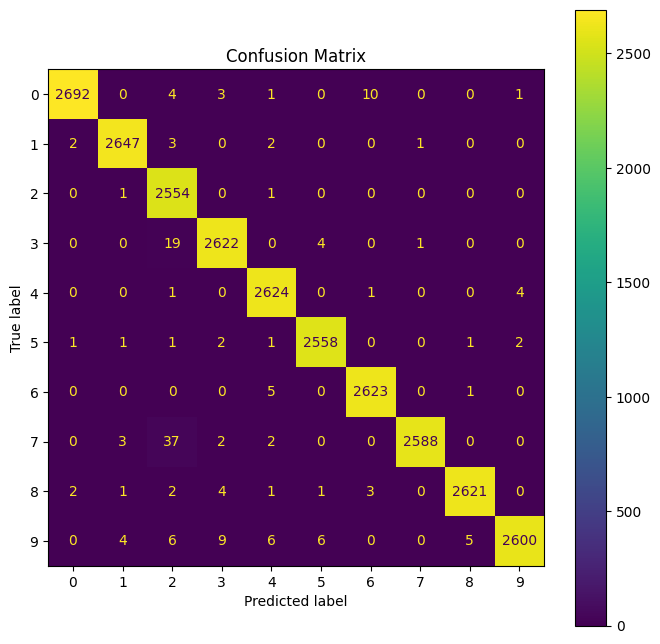

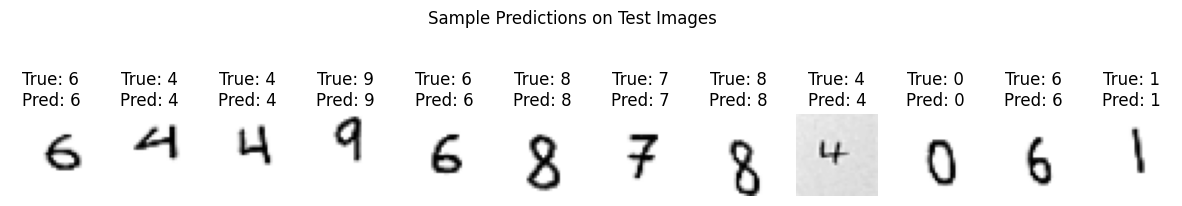

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predict on the test set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax)
plt.title("Confusion Matrix")
plt.show()

# Visualize predictions on random test images
num_samples = 12
indices = np.random.choice(len(X_test), num_samples, replace=False)
plt.figure(figsize=(15, 3))
for i, idx in enumerate(indices):
    plt.subplot(1, num_samples, i+1)
    plt.imshow(X_test[idx].reshape(32, 32), cmap='gray')
    plt.title(f"True: {y_true[idx]}\nPred: {y_pred[idx]}")
    plt.axis('off')
plt.suptitle("Sample Predictions on Test Images")
plt.show()

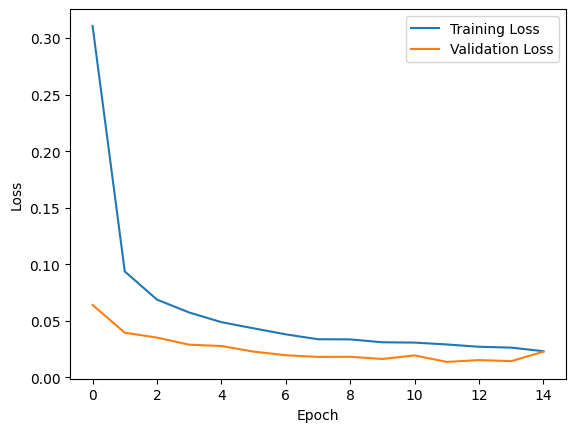

In [11]:
# Plot the loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

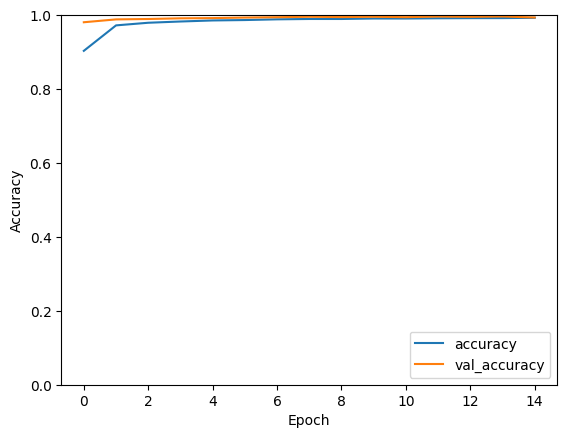

In [12]:
# Plot training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [14]:
# Save the trained model to a file
# Save to the models directory
model.save('cnn_model.keras')  # You can use .keras or .h5 extension